# 7d — EoMT DINOv2-Base, tête multi-échelle + Cosine Annealing

|                |                                                     |
| -------------- | --------------------------------------------------- |
| **Modèle**     | EoMT — DINOv2-Base + tête multi-échelle (4 couches) |
| **Backbone**   | `facebook/dinov2-base` (ViT-B/14, ~86M params)      |
| **Framework**  | PyTorch + HuggingFace `transformers==4.44.2`        |
| **Résolution** | 256 × 256                                           |


In [1]:
import sys
from pathlib import Path
ROOT = Path(".").resolve()
while not (ROOT / "scripts").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")


ROOT = /home/ui/PROJ9


In [2]:
import gc, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoConfig
from PIL import Image as PILImage
from sklearn.metrics import confusion_matrix as sk_cm

from scripts.config import ensure_dirs, resolve_split_csv, CITYSCAPES_DIR, EXP_DIR
from scripts.preprocessing import (
    load_rgb, load_mask_labelids, remap_to_groups, colorize_groups,
    CATEGORY_NAMES, IGNORE_LABEL, N_CLASSES, PALETTE
)
from scripts.augmentations import make_train_aug

ensure_dirs()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch : {torch.__version__}  |  Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


PyTorch : 2.0.1+cu117  |  Device : cuda
GPU  : NVIDIA GeForce GTX 1080 Ti
VRAM : 11.8 GB


## Configuration


In [ ]:
DINOV2_MODEL    = "facebook/dinov2-base"
N_LAYERS_USED   = 4
PROJ_DIM        = 256

SIZE_HW         = (256, 256)
BATCH           = 4
EPOCHS          = 50
LR              = 5e-4
T0              = 10
T_MULT          = 2
PATIENCE        = 15
EPOCHS_FT       = 30
LR_FT           = 5e-5
T0_FT           = 10
PATIENCE_FT     = 10
SEED            = 42
AUG             = True
GRAD_ACCUM      = 2

OUT_DIR = EXP_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"EOMT_DINOV2BASE_MULTISCALE_{SIZE_HW[0]}x{SIZE_HW[1]}"
    f"_L{N_LAYERS_USED}p{PROJ_DIM}_b{BATCH}xa{GRAD_ACCUM}"
    f"_cosine_T{T0}x{T_MULT}_e{EPOCHS}ft{EPOCHS_FT}_seed{SEED}"
)
BEST_PATH    = OUT_DIR / f"{RUN_NAME}.pt"
RESULTS_JSON = OUT_DIR / f"{RUN_NAME}_results.json"

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print("Run :", RUN_NAME)


Run : EOMT_DINOV2BASE_MULTISCALE_256x256_L4p256_b4xa2_cosine_T10x2_e50ft30_seed42


## Dataset


In [4]:
class CityscapesDatasetPT(Dataset):
    MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, df, base_dir, size_hw=(256,256), augment=None):
        self.df=df.reset_index(drop=True); self.base_dir=str(base_dir)
        self.H,self.W=size_hw; self.augment=augment

    def _resolve(self, row, ca, cr):
        if ca in row and isinstance(row[ca],str) and row[ca]: return row[ca]
        return f"{self.base_dir}/{row[cr]}"

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=load_rgb(self._resolve(row,"image_path","image_rel"))
        msk=remap_to_groups(load_mask_labelids(self._resolve(row,"mask_path","mask_rel")))
        img=img.resize((self.W,self.H),PILImage.BILINEAR)
        msk=msk.resize((self.W,self.H),PILImage.NEAREST)
        i=np.array(img,dtype=np.float32)/255.0
        m=np.array(msk,dtype=np.int64)
        if self.augment is not None:
            np.random.seed(idx*7919%(2**31))
            out=self.augment(image=(i*255).astype(np.uint8),mask=m.astype(np.uint8))
            i=out["image"].astype(np.float32)/255.0; m=out["mask"].astype(np.int64)
        i=(i-self.MEAN)/self.STD
        return torch.from_numpy(i.transpose(2,0,1)), torch.from_numpy(m)

df=pd.read_csv(resolve_split_csv())
train_df=df[df["split_final"]=="train"].copy()
val_df=df[df["split_final"]=="val"].copy()
test_df=df[df["split_final"]=="test"].copy()
print(f"Train:{len(train_df)} Val:{len(val_df)} Test:{len(test_df)}")

aug=make_train_aug() if AUG else None
train_ds=CityscapesDatasetPT(train_df,CITYSCAPES_DIR,SIZE_HW,augment=aug)
val_ds=CityscapesDatasetPT(val_df,CITYSCAPES_DIR,SIZE_HW)
test_ds=CityscapesDatasetPT(test_df,CITYSCAPES_DIR,SIZE_HW)
train_loader=DataLoader(train_ds,batch_size=BATCH,shuffle=True,num_workers=2,pin_memory=True)
val_loader=DataLoader(val_ds,batch_size=BATCH,shuffle=False,num_workers=2,pin_memory=True)
test_loader=DataLoader(test_ds,batch_size=BATCH,shuffle=False,num_workers=2,pin_memory=True)
print(f"Batches — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")


Train:2380 Val:500 Test:595
Batches — train:595 val:125 test:149


/home/ui/PROJ9/scripts/augmentations.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
/home/ui/PROJ9/.env_eomt/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Architecture — tête multi-échelle :


In [ ]:
class EoMTMultiScaleHead(nn.Module):
    def __init__(self, embed_dim=768, n_classes=8, img_hw=(256,256),
                 patch_size=14, n_layers=4, proj_dim=256):
        super().__init__()
        self.H, self.W   = img_hw
        self.ph          = img_hw[0] // patch_size
        self.pw          = img_hw[1] // patch_size
        self.n_spatial   = self.ph * self.pw
        self.n_layers    = n_layers

        self.layer_projs = nn.ModuleList([
            nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.LayerNorm(proj_dim))
            for _ in range(n_layers)
        ])

        self.fusion_weights = nn.Parameter(torch.ones(n_layers) / n_layers)

        self.up1  = nn.Sequential(
            nn.ConvTranspose2d(proj_dim, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up2  = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
        )
        self.head = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, n_classes, 1),
        )

    def forward(self, hidden_states):
        layers = hidden_states[-self.n_layers:]

        w = torch.softmax(self.fusion_weights, dim=0)

        fused = None
        for i, (h, proj) in enumerate(zip(layers, self.layer_projs)):
            B, N, C = h.shape
            spatial = h[:, N - self.n_spatial:, :]
            proj_out = proj(spatial)
            if fused is None:
                fused = w[i] * proj_out
            else:
                fused = fused + w[i] * proj_out

        B = fused.shape[0]
        x = fused.reshape(B, self.ph, self.pw, -1).permute(0, 3, 1, 2)
        x = self.up1(x)
        x = self.up2(x)
        x = F.interpolate(x, size=(self.H, self.W), mode="bilinear", align_corners=False)
        return self.head(x)


class EoMTModelMultiScale(nn.Module):
    def __init__(self, dinov2_name=DINOV2_MODEL, n_classes=N_CLASSES,
                 img_hw=SIZE_HW, n_layers=N_LAYERS_USED, proj_dim=PROJ_DIM,
                 trainable_encoder=False):
        super().__init__()
        cfg        = AutoConfig.from_pretrained(dinov2_name)
        patch_size = getattr(cfg, "patch_size", 14)
        embed_dim  = cfg.hidden_size
        print(f"Backbone  : {dinov2_name}")
        print(f"embed_dim : {embed_dim}  |  patch_size : {patch_size}")
        print(f"Couches utilisées : {n_layers} dernières sur {cfg.num_hidden_layers}")

        self.backbone = AutoModel.from_pretrained(dinov2_name)
        self.head     = EoMTMultiScaleHead(embed_dim, n_classes, img_hw,
                                            patch_size, n_layers, proj_dim)
        self.set_encoder_trainable(trainable_encoder)

    def set_encoder_trainable(self, v: bool):
        for p in self.backbone.parameters():
            p.requires_grad = bool(v)

    def forward(self, x):
        out = self.backbone(pixel_values=x.float(), output_hidden_states=True)
        return self.head(out.hidden_states)


model_pt = EoMTModelMultiScale(trainable_encoder=False).to(DEVICE)
n_total  = sum(p.numel() for p in model_pt.parameters())
n_train  = sum(p.numel() for p in model_pt.parameters() if p.requires_grad)
print(f"\nParams totaux       : {n_total:,}")
print(f"Params entraînables : {n_train:,}  (phase 1 — tête seulement)")

with torch.no_grad():
    dummy = torch.zeros(1, 3, *SIZE_HW).to(DEVICE)
    out   = model_pt(dummy)
    print(f"Forward OK — sortie : {out.shape}")
    if DEVICE == "cuda":
        print(f"VRAM utilisée  : {torch.cuda.memory_allocated()/1e9:.2f} GB")
del dummy, out; gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()


Backbone  : facebook/dinov2-base
embed_dim : 768  |  patch_size : 14
Couches utilisées : 4 dernières sur 12

Params totaux       : 87,838,796
Params entraînables : 1,258,316  (phase 1 — tête seulement)
Forward OK — sortie : torch.Size([1, 8, 256, 256])
VRAM utilisée  : 0.36 GB


## Loss & métriques


In [6]:
def ce_dice_loss(logits, targets, n_classes=N_CLASSES, ignore=IGNORE_LABEL, dice_w=0.5):
    ce      = F.cross_entropy(logits.float(), targets, ignore_index=ignore)
    valid   = (targets != ignore)
    t_s     = targets.clone(); t_s[~valid] = 0
    probs   = F.softmax(logits.float(), dim=1)
    t_oh    = F.one_hot(t_s, n_classes).permute(0,3,1,2).float()
    vf      = valid.unsqueeze(1).float()
    t_oh_m  = t_oh * vf
    probs_m = probs * vf
    inter   = (t_oh_m * probs_m).sum(dim=(0,2,3))
    denom   = (t_oh_m + probs_m).sum(dim=(0,2,3)) + 1e-6
    return ce + dice_w * (1.0 - (2.0 * inter / denom).mean())


def batch_miou(preds, targets, n_classes=N_CLASSES, ignore=IGNORE_LABEL):
    p = preds.cpu().numpy().flatten()
    t = targets.cpu().numpy().flatten()
    valid = t != ignore; p, t = p[valid], t[valid]
    iou = []
    for c in range(n_classes):
        tp=((p==c)&(t==c)).sum(); fp=((p==c)&(t!=c)).sum(); fn=((p!=c)&(t==c)).sum()
        d = tp+fp+fn
        iou.append(float(tp)/float(d) if d > 0 else 0.0)
    return float(np.mean(iou))


def run_epoch(model, loader, optimizer=None, phase="train", grad_accum=1):
    is_train = (phase == "train")
    model.train(is_train)
    tl, tm, n = 0.0, 0.0, 0
    if is_train and optimizer: optimizer.zero_grad()
    for step, (X, y) in enumerate(loader):
        X, y = X.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            logits = model(X)
            loss   = ce_dice_loss(logits, y) / grad_accum
        if is_train and optimizer:
            loss.backward()
            if (step + 1) % grad_accum == 0:
                optimizer.step(); optimizer.zero_grad()
        with torch.no_grad():
            miou = batch_miou(logits.detach().argmax(dim=1), y)
        tl += loss.item() * grad_accum; tm += miou; n += 1
        if n % 100 == 0:
            print(f"  [{n}/{len(loader)}] loss={tl/n:.4f} mIoU={tm/n:.4f}", end="\r")
    return tl/n, tm/n


## Phase 1 — Tête multi-échelle (encodeur gelé)


In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_pt.parameters()),
    lr=LR, weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T0, T_mult=T_MULT, eta_min=1e-6
)

history   = {"loss": [], "val_loss": [], "mIoU": [], "val_mIoU": [], "lr": []}
best_miou = -1.0; no_imp = 0
t0        = time.time()

for epoch in range(1, EPOCHS+1):
    t_ep       = time.time()
    tr_l, tr_m = run_epoch(model_pt, train_loader, optimizer, "train", GRAD_ACCUM)
    va_l, va_m = run_epoch(model_pt, val_loader,   None,      "val",   1)

    scheduler.step(epoch)
    current_lr = optimizer.param_groups[0]["lr"]

    history["loss"].append(tr_l);    history["val_loss"].append(va_l)
    history["mIoU"].append(tr_m);    history["val_mIoU"].append(va_m)
    history["lr"].append(current_lr)

    print(f"Ep {epoch:3d}/{EPOCHS}  loss={tr_l:.4f} mIoU={tr_m:.4f} | "
          f"val_loss={va_l:.4f} val_mIoU={va_m:.4f}  lr={current_lr:.2e}  [{time.time()-t_ep:.0f}s]")

    if va_m > best_miou:
        best_miou = va_m; no_imp = 0
        torch.save({"model": model_pt.state_dict(), "epoch": epoch,
                    "val_mIoU": va_m, "history": dict(history)}, BEST_PATH)
        print(f"  -> Checkpoint (val_mIoU={va_m:.4f})")
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f"  EarlyStopping ep {epoch}"); break

t_ph1    = time.time() - t0
ep_split = len(history["loss"])
print(f"\nPhase 1 : {t_ph1/60:.1f} min  |  Best val mIoU : {best_miou:.4f}")


Ep   1/50  loss=0.7996 mIoU=0.5452 | val_loss=0.5371 val_mIoU=0.6127  lr=4.88e-04  [113s]
  -> Checkpoint (val_mIoU=0.6127)
Ep   2/50  loss=0.5763 mIoU=0.6046 | val_loss=0.4813 val_mIoU=0.6283  lr=4.52e-04  [112s]
  -> Checkpoint (val_mIoU=0.6283)
Ep   3/50  loss=0.5382 mIoU=0.6179 | val_loss=0.4657 val_mIoU=0.6339  lr=3.97e-04  [113s]
  -> Checkpoint (val_mIoU=0.6339)
Ep   4/50  loss=0.5190 mIoU=0.6264 | val_loss=0.4483 val_mIoU=0.6422  lr=3.28e-04  [117s]
  -> Checkpoint (val_mIoU=0.6422)
Ep   5/50  loss=0.5067 mIoU=0.6316 | val_loss=0.4403 val_mIoU=0.6469  lr=2.51e-04  [113s]
  -> Checkpoint (val_mIoU=0.6469)
Ep   6/50  loss=0.4935 mIoU=0.6368 | val_loss=0.4325 val_mIoU=0.6497  lr=1.73e-04  [112s]
  -> Checkpoint (val_mIoU=0.6497)
Ep   7/50  loss=0.4858 mIoU=0.6398 | val_loss=0.4276 val_mIoU=0.6519  lr=1.04e-04  [114s]
  -> Checkpoint (val_mIoU=0.6519)
Ep   8/50  loss=0.4744 mIoU=0.6449 | val_loss=0.4233 val_mIoU=0.6538  lr=4.87e-05  [114s]
  -> Checkpoint (val_mIoU=0.6538)
Ep   9/5

## Phase 2 — Fine-tuning (encodeur + tête)

On dégèle l'encodeur + Cosine Annealing


In [ ]:
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model_pt.load_state_dict(ckpt["model"])
model_pt.set_encoder_trainable(True)

optimizer_ft = torch.optim.AdamW([
    {"params": model_pt.head.parameters(),     "lr": LR_FT},
    {"params": model_pt.backbone.parameters(), "lr": LR_FT * 0.1},
], weight_decay=1e-4)

scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_ft, T_0=T0_FT, T_mult=2, eta_min=1e-7
)

no_imp_ft = 0; t0_ft = time.time()

for epoch in range(1, EPOCHS_FT+1):
    t_ep       = time.time()
    tr_l, tr_m = run_epoch(model_pt, train_loader, optimizer_ft, "train", GRAD_ACCUM)
    va_l, va_m = run_epoch(model_pt, val_loader,   None,         "val",   1)
    scheduler_ft.step(epoch)
    current_lr = optimizer_ft.param_groups[0]["lr"]

    history["loss"].append(tr_l);    history["val_loss"].append(va_l)
    history["mIoU"].append(tr_m);    history["val_mIoU"].append(va_m)
    history["lr"].append(current_lr)

    print(f"FT {epoch:3d}/{EPOCHS_FT}  loss={tr_l:.4f} mIoU={tr_m:.4f} | "
          f"val_loss={va_l:.4f} val_mIoU={va_m:.4f}  lr={current_lr:.2e}  [{time.time()-t_ep:.0f}s]")

    if va_m > best_miou:
        best_miou = va_m; no_imp_ft = 0
        torch.save({"model": model_pt.state_dict(), "epoch": EPOCHS+epoch,
                    "val_mIoU": va_m, "history": dict(history)}, BEST_PATH)
        print(f"  -> Meilleur FT (val_mIoU={va_m:.4f})")
    else:
        no_imp_ft += 1
        if no_imp_ft >= PATIENCE_FT:
            print(f"  EarlyStopping FT ep {epoch}"); break

t_ph2 = time.time() - t0_ft
t_tot = t_ph1 + t_ph2
print(f"\nTotal : {t_tot/60:.1f} min")


FT   1/30  loss=0.4117 mIoU=0.6799 | val_loss=0.3575 val_mIoU=0.6964  lr=4.88e-05  [176s]
  -> Meilleur FT (val_mIoU=0.6964)
FT   2/30  loss=0.3847 mIoU=0.6960 | val_loss=0.3472 val_mIoU=0.7033  lr=4.52e-05  [173s]
  -> Meilleur FT (val_mIoU=0.7033)
FT   3/30  loss=0.3728 mIoU=0.7034 | val_loss=0.3457 val_mIoU=0.7043  lr=3.97e-05  [173s]
  -> Meilleur FT (val_mIoU=0.7043)
FT   4/30  loss=0.3653 mIoU=0.7078 | val_loss=0.3369 val_mIoU=0.7111  lr=3.28e-05  [173s]
  -> Meilleur FT (val_mIoU=0.7111)
FT   5/30  loss=0.3535 mIoU=0.7147 | val_loss=0.3344 val_mIoU=0.7116  lr=2.50e-05  [174s]
  -> Meilleur FT (val_mIoU=0.7116)
FT   6/30  loss=0.3443 mIoU=0.7199 | val_loss=0.3295 val_mIoU=0.7151  lr=1.73e-05  [173s]
  -> Meilleur FT (val_mIoU=0.7151)
FT   7/30  loss=0.3392 mIoU=0.7225 | val_loss=0.3281 val_mIoU=0.7166  lr=1.04e-05  [173s]
  -> Meilleur FT (val_mIoU=0.7166)
FT   8/30  loss=0.3335 mIoU=0.7257 | val_loss=0.3259 val_mIoU=0.7182  lr=4.87e-06  [176s]
  -> Meilleur FT (val_mIoU=0.7182)


## Évaluation finale


In [9]:
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model_pt.load_state_dict(ckpt["model"]); model_pt.eval()

def evaluate_loader(model, loader):
    tl, tm, n = 0.0, 0.0, 0; all_p, all_t = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X); tl += ce_dice_loss(logits, y).item()
            preds  = logits.argmax(dim=1); tm += batch_miou(preds, y); n += 1
            all_p.append(preds.cpu()); all_t.append(y.cpu())
    return tl/n, tm/n, torch.cat(all_p), torch.cat(all_t)

val_loss,  val_miou,  vp, vt  = evaluate_loader(model_pt, val_loader)
test_loss, test_miou, tp_, tt = evaluate_loader(model_pt, test_loader)
print(f"Val  — Loss:{val_loss:.4f}  mIoU:{val_miou:.4f}")
print(f"Test — Loss:{test_loss:.4f}  mIoU:{test_miou:.4f}")


Val  — Loss:0.3093  mIoU:0.7338
Test — Loss:0.2791  mIoU:0.7661


In [10]:
def per_class_iou_tensors(preds, targets, n_classes=N_CLASSES, ignore=IGNORE_LABEL):
    p=preds.numpy().flatten(); t=targets.numpy().flatten(); valid=t!=ignore
    conf=sk_cm(t[valid],p[valid],labels=list(range(n_classes)))
    iou=[]
    for c in range(n_classes):
        tp=conf[c,c]; fn=conf[c,:].sum()-tp; fp=conf[:,c].sum()-tp; d=tp+fn+fp
        iou.append(float(tp)/float(d) if d>0 else 0.0)
    return iou

per_class_iou = per_class_iou_tensors(tp_, tt)
miou_manual   = np.mean(per_class_iou)
print(f"mIoU test = {miou_manual:.4f}\n")
for i,(name,v) in enumerate(zip(CATEGORY_NAMES, per_class_iou)):
    print(f"  {i} {name:<15} {v:.4f}  {'|'*int(v*30)}")


mIoU test = 0.7844

  0 void            0.8333  ||||||||||||||||||||||||
  1 flat            0.9693  |||||||||||||||||||||||||||||
  2 construction    0.8492  |||||||||||||||||||||||||
  3 object          0.3824  |||||||||||
  4 nature          0.8481  |||||||||||||||||||||||||
  5 sky             0.8987  ||||||||||||||||||||||||||
  6 human           0.6272  ||||||||||||||||||
  7 vehicle         0.8667  ||||||||||||||||||||||||||


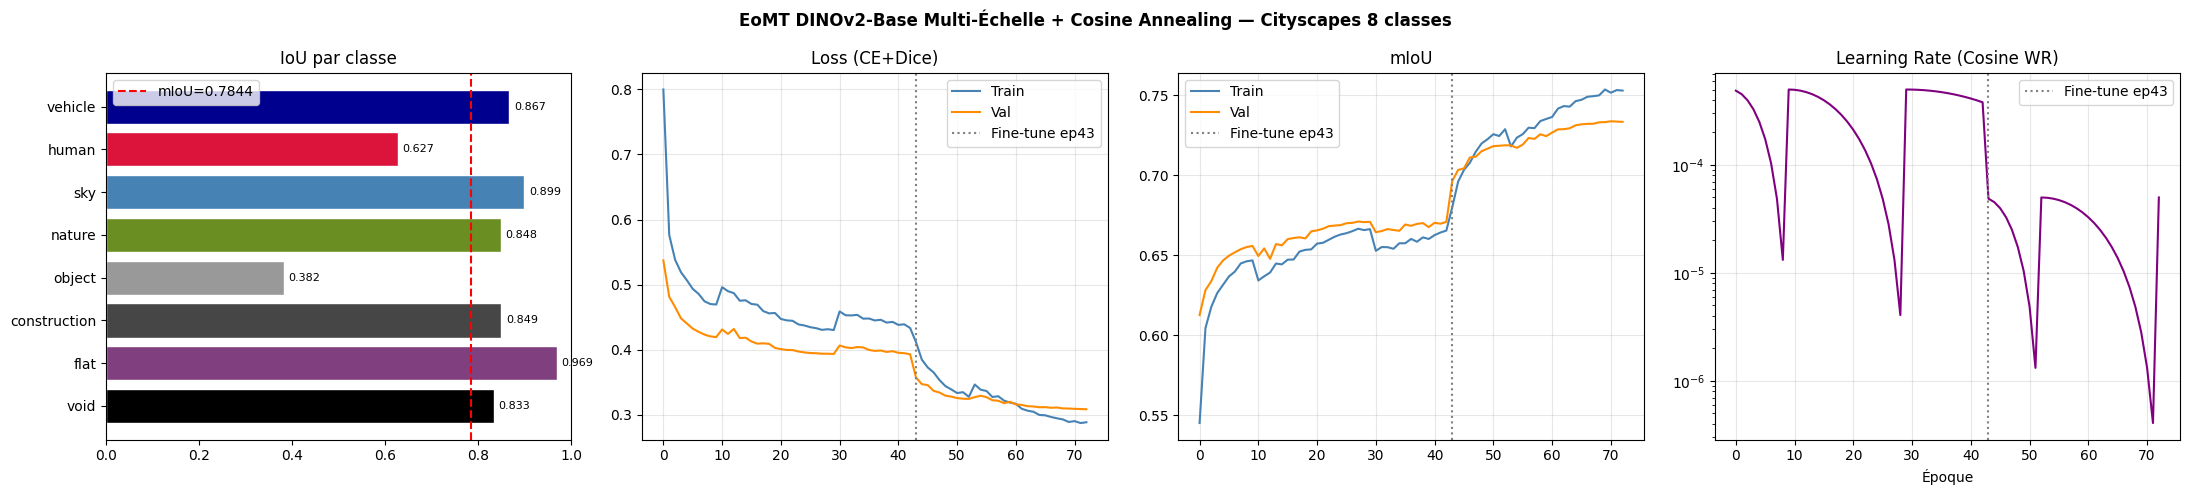

In [ ]:
colors = [tuple(c/255 for c in PALETTE[i]) for i in range(N_CLASSES)]
all_loss  = history["loss"];     all_vloss = history["val_loss"]
all_iou   = history["mIoU"];     all_viou  = history["val_mIoU"]
all_lr    = history["lr"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# IoU par classe
axes[0].barh(CATEGORY_NAMES, per_class_iou, color=colors, edgecolor="white")
axes[0].axvline(miou_manual, color="red", linestyle="--",
                label=f"mIoU={miou_manual:.4f}")
axes[0].set_xlim(0, 1); axes[0].legend()
axes[0].set_title("IoU par classe")
for i,v in enumerate(per_class_iou):
    axes[0].text(v+0.01, i, f"{v:.3f}", va="center", fontsize=8)

# Loss
axes[1].plot(all_loss,  label="Train", color="steelblue")
axes[1].plot(all_vloss, label="Val",   color="darkorange")
axes[1].axvline(ep_split, color="grey", linestyle=":", label=f"Fine-tune ep{ep_split}")
axes[1].set_title("Loss (CE+Dice)"); axes[1].legend(); axes[1].grid(alpha=0.3)

# mIoU
axes[2].plot(all_iou,  label="Train", color="steelblue")
axes[2].plot(all_viou, label="Val",   color="darkorange")
axes[2].axvline(ep_split, color="grey", linestyle=":", label=f"Fine-tune ep{ep_split}")
axes[2].set_title("mIoU"); axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(all_lr, color="purple", linewidth=1.5)
axes[3].axvline(ep_split, color="grey", linestyle=":", label=f"Fine-tune ep{ep_split}")
axes[3].set_title("Learning Rate (Cosine WR)")
axes[3].set_xlabel("Époque"); axes[3].set_yscale("log")
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.suptitle("EoMT DINOv2-Base Multi-Échelle + Cosine Annealing — Cityscapes 8 classes",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUT_DIR / f"{RUN_NAME}_summary.png"), dpi=120)
plt.show()


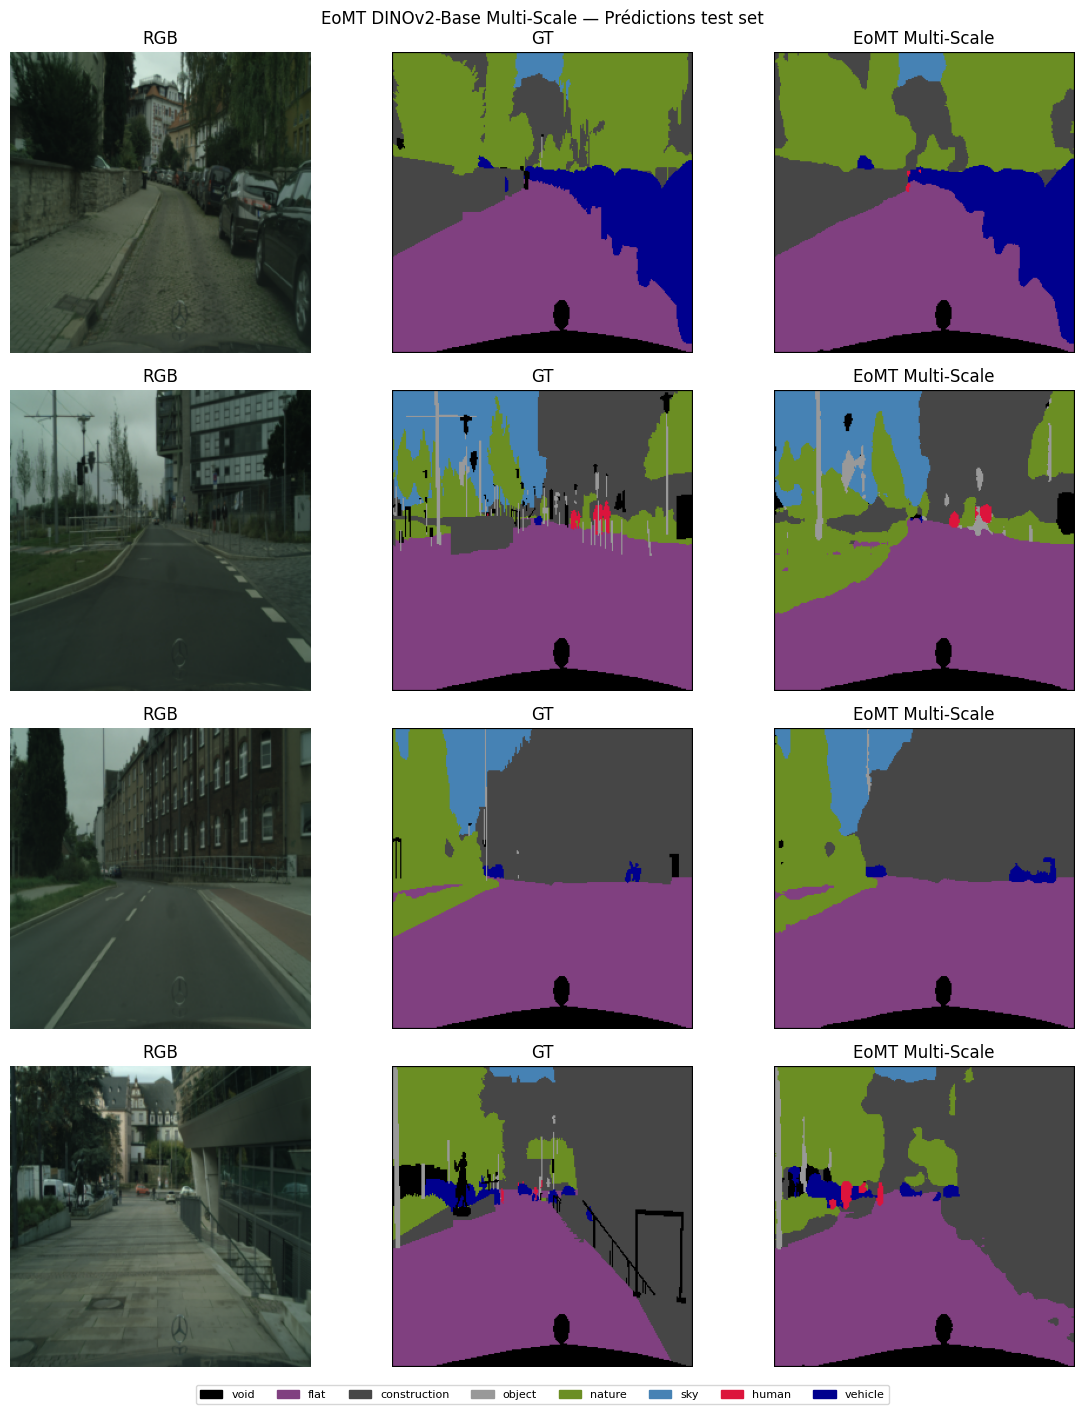

In [ ]:
MEAN_NP = CityscapesDatasetPT.MEAN; STD_NP = CityscapesDatasetPT.STD
model_pt.eval()
X_b, y_b = next(iter(test_loader))
X_s, y_s = X_b[:4].to(DEVICE), y_b[:4]
with torch.no_grad():
    pr = model_pt(X_s).argmax(dim=1).cpu()

fig, axes = plt.subplots(4, 3, figsize=(12, 4*3.5))
for i in range(4):
    arr  = np.clip(X_s[i].cpu().permute(1,2,0).numpy()*STD_NP+MEAN_NP, 0, 1)
    arr  = (arr*255).astype(np.uint8)
    gt_c = colorize_groups(PILImage.fromarray(y_s[i].numpy().astype(np.uint8)))
    pr_c = colorize_groups(PILImage.fromarray(pr[i].numpy().astype(np.uint8)))
    axes[i,0].imshow(arr);  axes[i,0].set_title("RGB")
    axes[i,1].imshow(gt_c); axes[i,1].set_title("GT")
    axes[i,2].imshow(pr_c); axes[i,2].set_title("EoMT Multi-Scale")
    for ax in axes[i]: ax.axis("off")
patches = [mpatches.Patch(color=[c/255 for c in PALETTE[j]], label=CATEGORY_NAMES[j])
           for j in range(N_CLASSES)]
fig.legend(handles=patches, loc="lower center", ncol=N_CLASSES,
           bbox_to_anchor=(0.5,-0.02), fontsize=8)
plt.suptitle("EoMT DINOv2-Base Multi-Scale — Prédictions test set")
plt.tight_layout()
plt.savefig(str(OUT_DIR / f"{RUN_NAME}_preds.png"), dpi=100, bbox_inches="tight")
plt.show()


In [13]:
results = {
    "run_name"       : RUN_NAME,
    "model"          : "eomt_dinov2_base_multiscale",
    "encoder"        : "dinov2_base",
    "head"           : f"multi_scale_{N_LAYERS_USED}layers_proj{PROJ_DIM}",
    "scheduler"      : f"cosine_warm_restarts_T{T0}x{T_MULT}",
    "framework"      : "pytorch",
    "input_shape"    : list(SIZE_HW) + [3],
    "best_path"      : str(BEST_PATH),
    "train_time_sec" : float(t_tot),
    "epochs_phase1"  : ep_split,
    "epochs_phase2"  : len(history["loss"]) - ep_split,
    "val_loss"       : float(val_loss),
    "val_mIoU"       : float(val_miou),
    "test_loss"      : float(test_loss),
    "test_mIoU"      : float(test_miou),
    "per_class_iou"  : {CATEGORY_NAMES[i]: round(per_class_iou[i], 4) for i in range(N_CLASSES)},
    "history"        : {
        "loss"     : [float(v) for v in history["loss"]],
        "val_loss" : [float(v) for v in history["val_loss"]],
        "mIoU"     : [float(v) for v in history["mIoU"]],
        "val_mIoU" : [float(v) for v in history["val_mIoU"]],
        "lr"       : [float(v) for v in history["lr"]],
    },
}
with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)

print(f"JSON : {RESULTS_JSON}")
print(f"{'='*60}")
print(f"EoMT DINOv2-Base Multi-Scale + Cosine Annealing")
print(f"  Val  mIoU : {results['val_mIoU']:.4f}")
print(f"  Test mIoU : {results['test_mIoU']:.4f}")
print(f"  Durée     : {t_tot/60:.1f} min")
print(f"  Tête      : {results['head']}")
print(f"  Scheduler : {results['scheduler']}")
print(f"{'='*60}")


JSON : /home/ui/PROJ9/out/experiments/EOMT_DINOV2BASE_MULTISCALE_256x256_L4p256_b4xa2_cosine_T10x2_e50ft30_seed42_results.json
EoMT DINOv2-Base Multi-Scale + Cosine Annealing
  Val  mIoU : 0.7338
  Test mIoU : 0.7661
  Durée     : 168.4 min
  Tête      : multi_scale_4layers_proj256
  Scheduler : cosine_warm_restarts_T10x2
